# 05. Evaluación e interpretación

## Objetivo
Evaluar comparativamente los modelos entrenados, seleccionar el modelo con mejor desempeño para el problema planteado e interpretar sus resultados mediante métricas, matrices de confusión, curvas ROC e importancia de variables.

In [23]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))
    
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

from config.paths import REPORTS_DIR
from config.paths import REPORTS_DIR, ensure_project_dirs

In [24]:
display(Markdown("# 05. Evaluación e interpretación"))
display(Markdown("## Resumen final de modelos"))

display(
    results_df.style
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
    .background_gradient(subset=["Recall", "F1-score", "ROC-AUC"], cmap="Blues")
)

# 05. Evaluación e interpretación

## Resumen final de modelos

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Regresión Logística,0.8445,0.8578,0.8804,0.8689,0.9188
1,KNN,0.8267,0.8303,0.8849,0.8568,0.8888
2,Random Forest,0.8237,0.8211,0.8935,0.8558,0.9076
3,Árbol de Decisión,0.8206,0.8357,0.8635,0.8494,0.8908


In [25]:
best_model_name = results_df.iloc[0]["Modelo"]
best_model = models[best_model_name]
best_pred = predictions[best_model_name]
best_prob = probabilities[best_model_name]

display(Markdown("## Modelo final seleccionado"))
display(Markdown(
    f"El modelo seleccionado fue **{best_model_name}**, "
    f"por presentar el mejor equilibrio entre **Recall**, **F1-score** y **ROC-AUC**."
))

## Modelo final seleccionado

El modelo seleccionado fue **Regresión Logística**, por presentar el mejor equilibrio entre **Recall**, **F1-score** y **ROC-AUC**.

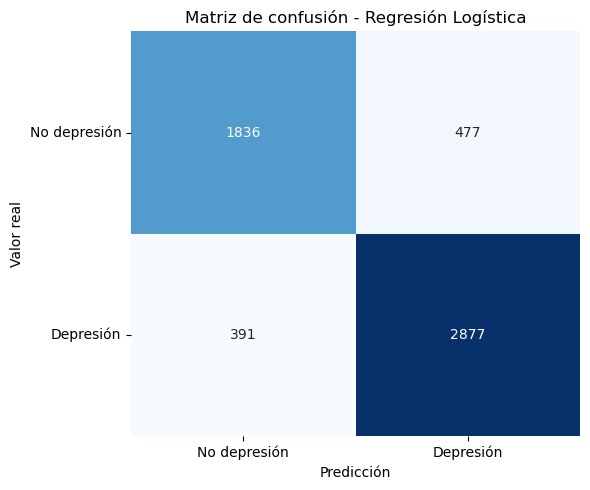

In [26]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title(f"Matriz de confusión - {best_model_name}")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks([0.5, 1.5], ["No depresión", "Depresión"])
plt.yticks([0.5, 1.5], ["No depresión", "Depresión"], rotation=0)
plt.tight_layout()
plt.show()

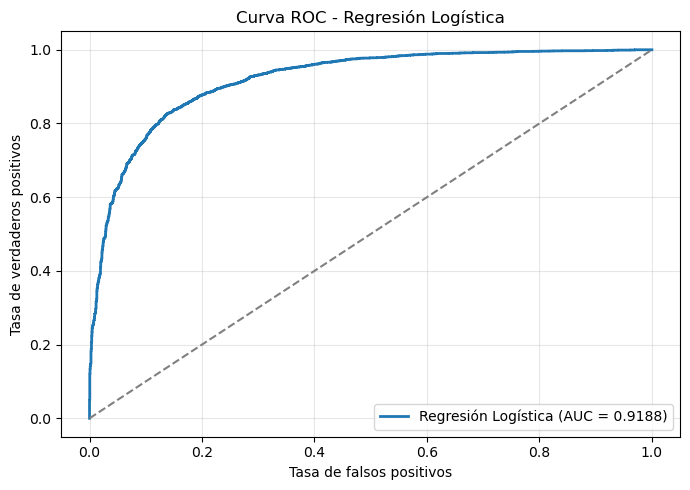

In [27]:
fpr, tpr, _ = roc_curve(y_test, best_prob)
auc_value = roc_auc_score(y_test, best_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"{best_model_name} (AUC = {auc_value:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title(f"Curva ROC - {best_model_name}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
if best_model_name == "Regresión Logística":
    feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
    coefs = best_model.named_steps["model"].coef_[0]
    
    coef_df = pd.DataFrame({
        "Variable": feature_names,
        "Coeficiente": coefs
    }).sort_values("Coeficiente", ascending=False)
    
    display(Markdown("## Variables con mayor efecto positivo"))
    display(coef_df.head(10))
    
    display(Markdown("## Variables con mayor efecto negativo"))
    display(coef_df.tail(10))

## Variables con mayor efecto positivo

,Variable,Coeficiente
18,cat__have_you_ever_had_suicidal_thoughts__Yes,1.293153
1,num__academic_pressure,1.165900
5,num__financial_stress,0.814050
16,cat__dietary_habits_Unhealthy,0.570693
4,num__work_study_hours,0.437496
10,cat__sleep_duration_Less than 5 hours,0.351154
33,cat__degree_grouped_LLB,0.255995
58,cat__city_grouped_Kolkata,0.233412
53,cat__city_grouped_Hyderabad,0.232142
47,cat__city_grouped_Ahmedabad,0.230412


## Variables con mayor efecto negativo

,Variable,Coeficiente
32,cat__degree_grouped_Class 12,-0.198517
11,cat__sleep_duration_More than 8 hours,-0.257448
55,cat__city_grouped_Jaipur,-0.259538
46,cat__city_grouped_Agra,-0.288531
3,num__study_satisfaction,-0.323573
62,cat__city_grouped_Mumbai,-0.347930
63,cat__city_grouped_Nagpur,-0.390554
13,cat__dietary_habits_Healthy,-0.517061
0,num__age,-0.593301
17,cat__have_you_ever_had_suicidal_thoughts__No,-1.220341


In [29]:
results_df.to_csv(REPORTS_DIR / "resultados_finales_modelos.csv", index=False)

In [30]:
ensure_project_dirs()

df_dashboard = X_test.copy()
df_dashboard["depression_real"] = y_test.values
df_dashboard["depression_pred"] = best_pred
df_dashboard["probabilidad_depresion"] = best_prob

df_dashboard.to_csv(REPORTS_DIR / "dashboard_base.csv", index=False)
results_df.to_csv(REPORTS_DIR / "resultados_modelos.csv", index=False)

## Interpretación de resultados

La evaluación comparativa muestra que los modelos presentan comportamientos distintos frente al problema de clasificación. Aunque el accuracy ofrece una visión general del porcentaje de aciertos, en este caso se dio mayor importancia al recall y al F1-score, debido a que el interés principal es identificar correctamente los casos positivos de depresión.

La matriz de confusión permitió analizar el tipo de errores cometidos por cada modelo, especialmente los falsos negativos, que representan estudiantes con depresión no detectados. Por su parte, la curva ROC permitió comparar la capacidad de discriminación de los modelos a distintos umbrales de decisión.

Finalmente, el modelo seleccionado se eligió no solo por su desempeño global, sino también por su utilidad interpretativa y su capacidad para apoyar decisiones analíticas dentro del contexto del problema.

## Conclusiones

En esta fase se evaluaron los cuatro modelos de clasificación entrenados previamente, utilizando métricas adecuadas para clasificación binaria, matrices de confusión y curvas ROC. Esta evaluación permitió identificar diferencias en desempeño entre los modelos y seleccionar el más adecuado para el problema de predicción de depresión en estudiantes.

Además, se interpretaron los resultados del modelo final a partir de la importancia de variables o coeficientes, así como del análisis de errores de clasificación. Esto permitió no solo elegir el mejor modelo, sino también comprender mejor qué variables influyen en la predicción y qué limitaciones presenta el sistema.